# Case Study: Training a Neural Network on a Toy Spiral Dataset

In this section, we will walk through a complete implementation of a toy Neural Network in two dimensions.

We will first implement a simple linear classifier and then extend it to a 2-layer Neural Network.

As we will see, this extension is surprisingly simple and requires only a few changes.

---

## Generating Some Data

We first generate a classification dataset that is not easily linearly separable.

A common example is the **spiral dataset**.

The toy spiral dataset consists of three classes:

- blue,
- red,
- yellow.

These classes are arranged in a spiral-like structure and cannot be separated well using a simple linear decision boundary.

---

## Dataset Dimensions

In this example:

- $N = 100$ is the number of points per class,
- $D = 2$ is the dimensionality of the data,
- $K = 3$ is the number of classes.

Therefore, the full dataset contains:

$$
N \times K = 100 \times 3 = 300
$$

data points.

Each data point has two features, so the data matrix has shape:

$$
X \in \mathbb{R}^{300 \times 2}
$$

The label vector contains one class label for each data point:

$$
y \in \mathbb{R}^{300}
$$

---

## Spiral Dataset

The spiral dataset is useful because it is simple to visualize but difficult for a linear classifier.

A linear classifier can only draw straight decision boundaries.

However, the spiral classes require curved and nonlinear decision boundaries.

This makes the dataset a good toy example for showing why Neural Networks are more powerful than linear models.

---

## Data Preprocessing

Normally, we would preprocess the dataset so that each feature has:

- zero mean,
- unit standard deviation.

This is often done to make optimization easier and more stable.

However, in this example, the features are already in a reasonable range:

$$
[-1, 1]
$$

Therefore, we skip the preprocessing step.

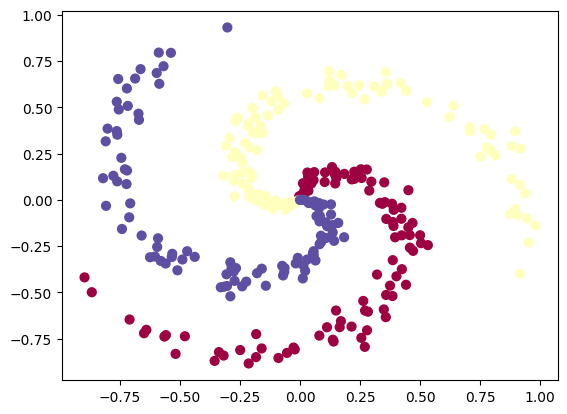

In [4]:
import numpy as np
import matplotlib.pyplot as plt



N = 100  # number of points per class
D = 2    # dimensionality
K = 3    # number of classes

X = np.zeros((N * K, D))          # data matrix, each row is a single example
y = np.zeros(N * K, dtype='uint8') # class labels

for j in range(K):
    ix = range(N * j, N * (j + 1))
    r = np.linspace(0.0, 1, N)  # radius
    t = np.linspace(j * 4, (j + 1) * 4, N) + np.random.randn(N) * 0.2  # theta

    X[ix] = np.c_[r * np.sin(t), r * np.cos(t)]
    y[ix] = j

# visualize the data
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.show()

# Training a Softmax Linear Classifier

## Initialize the Parameters

We will first train a Softmax classifier on the spiral classification dataset.

As discussed in previous sections, the Softmax classifier has:

- a linear score function,
- a cross-entropy loss function.

The parameters of the linear classifier consist of:

- a weight matrix $W$,
- a bias vector $b$.

The weight matrix maps the input features to class scores.

In this example:

- $D = 2$ is the dimensionality of the data,
- $K = 3$ is the number of classes.

Therefore, the weight matrix has shape:

$$
W \in \mathbb{R}^{D \times K}
$$

and the bias vector has shape:

$$
b \in \mathbb{R}^{1 \times K}
$$

Since $D = 2$ and $K = 3$, we have:

$$
W \in \mathbb{R}^{2 \times 3}
$$

and:

$$
b \in \mathbb{R}^{1 \times 3}
$$

In [13]:
# initialize parameters randomly
W = 0.01 * np.random.randn(D, K)
b = np.zeros((1, K))

step_size = 1e-0
reg = 1e-3

---

## Compute the Class Scores

Since this is a linear classifier, all class scores can be computed in parallel using a single matrix multiplication.

The score function is:

$$
s = XW + b
$$

where:

- $X$ is the data matrix,
- $W$ is the weight matrix,
- $b$ is the bias vector,
- $s$ is the matrix of class scores.

In this example, we have 300 data points in 2 dimensions.

Therefore:

$$
X \in \mathbb{R}^{300 \times 2}
$$

and:

$$
W \in \mathbb{R}^{2 \times 3}
$$

After matrix multiplication, the score matrix has shape:

$$
scores \in \mathbb{R}^{300 \times 3}
$$

Each row contains the class scores for one example.

Since there are three classes, each row contains three scores corresponding to:

- blue,
- red,
- yellow.

In [6]:
# compute class scores for a linear classifier
scores = np.dot(X, W) + b

---

## Compute the Loss

The second key ingredient is the loss function.

A loss function is a differentiable objective that measures how unhappy we are with the computed class scores.

Intuitively, we want the correct class to have a higher score than the incorrect classes.

When this happens, the loss should be low.

When the correct class does not have a high score, the loss should be high.

For this example, we use the cross-entropy loss associated with the Softmax classifier.

---

## Softmax Loss for One Example

Let $f$ be the vector of class scores for a single example.

For example, since we have three classes:

$$
f \in \mathbb{R}^{3}
$$

The Softmax classifier computes the loss for example $i$ as:

$$
L_i = -\log \left( \frac{e^{f_{y_i}}}{\sum_j e^{f_j}} \right)
$$

Here:

- $f_{y_i}$ is the score of the correct class,
- $\sum_j e^{f_j}$ is the sum of exponentiated scores over all classes,
- $L_i$ is the loss for example $i$.

---

## Interpretation of Softmax

The Softmax classifier interprets each element of $f$ as an unnormalized log probability.

First, we exponentiate the scores:

$$
e^{f_j}
$$

This gives unnormalized probabilities.

Then, we normalize them by dividing by the sum over all classes:

$$
p_j = \frac{e^{f_j}}{\sum_k e^{f_k}}
$$

The result is a probability distribution over classes.

The probability assigned to the correct class is:

$$
p_{y_i} = \frac{e^{f_{y_i}}}{\sum_j e^{f_j}}
$$

This value is always between 0 and 1.

If the probability of the correct class is close to 0, then:

$$
-\log(p_{y_i}) \rightarrow \infty
$$

If the probability of the correct class is close to 1, then:

$$
-\log(p_{y_i}) \rightarrow 0
$$

because:

$$
\log(1) = 0
$$

Therefore, the Softmax loss is low when the correct class probability is high, and high when the correct class probability is low.

---

## Full Softmax Classifier Loss

The full Softmax classifier loss is the average cross-entropy loss over all training examples plus a regularization term:

$$
L = \frac{1}{N}\sum_i L_i + \frac{1}{2}\lambda \sum_k \sum_l W_{k,l}^{2}
$$

The first term is the data loss:

$$
\frac{1}{N}\sum_i L_i
$$

The second term is the regularization loss:

$$
\frac{1}{2}\lambda \sum_k \sum_l W_{k,l}^{2}
$$

Here:

- $N$ is the number of training examples,
- $\lambda$ is the regularization strength,
- $W$ is the weight matrix.

The regularization term discourages very large weights and helps reduce overfitting.

---

## Computing Probabilities

Given the class scores, we can compute the Softmax probabilities.

First, we exponentiate the scores:

$$
e^{scores}
$$

Then, we normalize each row so that the probabilities for each example sum to 1.

In [7]:
num_examples = X.shape[0]

# get unnormalized probabilities
exp_scores = np.exp(scores)

# normalize them for each example
probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

After this step, `probs` has shape:

$$
probs \in \mathbb{R}^{300 \times 3}
$$

Each row contains the class probabilities for one example.

Since each row is normalized, the probabilities in every row sum to:

$$
1
$$

---

## Correct Class Log Probabilities

Next, we select the probabilities assigned to the correct classes.

For each example, we take the probability corresponding to its true label and compute the negative logarithm.

In [8]:
correct_logprobs = -np.log(probs[range(num_examples), y])

The array `correct_logprobs` is a one-dimensional array.

It contains the loss contribution for each training example.

The data loss is the average of these values:

$$
L_{\text{data}} = \frac{1}{N}\sum_i L_i
$$

The total loss is obtained by adding the regularization loss:

$$
L = L_{\text{data}} + L_{\text{reg}}
$$

In [14]:
# compute the loss: average cross-entropy loss and regularization
data_loss = np.sum(correct_logprobs) / num_examples
reg_loss = 0.5 * reg * np.sum(W * W)
loss = data_loss + reg_loss

In this code, the regularization strength $\lambda$ is stored in the variable `reg`.

The factor:

$$
0.5
$$

is included for convenience.

It simplifies the gradient of the regularization term later.

At initialization, the parameters are small random values.

Therefore, all class scores are close to zero, and all class probabilities are approximately equal.

Since there are 3 classes, each class receives probability approximately:

$$
\frac{1}{3}
$$

So the initial loss is approximately:

$$
-\log\left(\frac{1}{3}\right)
$$

which is about:

$$
1.1
$$

The goal of training is to make the loss as small as possible.

The absolute lower bound is:

$$
0
$$

A lower loss means that the model assigns higher probabilities to the correct classes.

# Computing the Analytic Gradient with Backpropagation

We now have a way to evaluate the loss.

The next step is to minimize it.

We do this using gradient descent.

We start with random parameters and compute the gradient of the loss with respect to the parameters.

The gradient tells us how each parameter should change in order to decrease the loss.

---

## Gradient of the Softmax Loss

Let $p$ be the vector of normalized probabilities.

For a single example, the Softmax probability for class $k$ is:

$$
p_k = \frac{e^{f_k}}{\sum_j e^{f_j}}
$$

The loss for example $i$ is:

$$
L_i = -\log(p_{y_i})
$$

We want to compute how the scores $f_k$ should change in order to reduce the loss.

In other words, we want:

$$
\frac{\partial L_i}{\partial f_k}
$$

After applying the chain rule, the result simplifies to:

$$
\frac{\partial L_i}{\partial f_k} = p_k - \mathbb{1}(y_i = k)
$$

Here:

- $p_k$ is the predicted probability of class $k$,
- $\mathbb{1}(y_i = k)$ is 1 if class $k$ is the correct class,
- otherwise it is 0.

---

## Intuition Behind the Gradient

Suppose the predicted probabilities are:

$$
p = [0.2,\ 0.3,\ 0.5]
$$

and the correct class is the middle class.

Then the gradient on the scores is:

$$
df = [0.2,\ -0.7,\ 0.5]
$$

This is intuitive.

The incorrect classes have positive gradients:

$$
0.2
$$

and:

$$
0.5
$$

This means increasing their scores would increase the loss.

The correct class has a negative gradient:

$$
-0.7
$$

This means increasing the correct class score would decrease the loss.

So the gradient pushes the model to increase the score of the correct class and decrease the scores of incorrect classes.

In [10]:
dscores = probs
dscores[range(num_examples), y] -= 1
dscores /= num_examples

The variable `dscores` stores the gradient of the loss with respect to the class scores.

Since:

$$
scores = XW + b
$$

we can now backpropagate this gradient into the parameters $W$ and $b$.

In [15]:
dW = np.dot(X.T, dscores)
db = np.sum(dscores, axis=0, keepdims=True)
dW += reg * W

The term:

$$
dW
$$

is the gradient of the loss with respect to the weights.

The term:

$$
db
$$

is the gradient of the loss with respect to the biases.

We also add the regularization gradient:

$$
\lambda W
$$

This comes from the regularization term:

$$
\frac{1}{2}\lambda W^2
$$

Its derivative is:

$$
\lambda W
$$

The factor $\frac{1}{2}$ was included earlier to make this derivative simple.

---

# Performing a Parameter Update

Now that we have computed the gradients, we know how each parameter affects the loss.

To reduce the loss, we update the parameters in the negative gradient direction.

The update rule is:

$$
W \leftarrow W - \alpha dW
$$

$$
b \leftarrow b - \alpha db
$$

where $\alpha$ is the step size or learning rate.


In [16]:
# perform a parameter update
W += -step_size * dW
b += -step_size * db

# Putting It All Together: Training a Softmax Classifier

Now we can combine all the previous steps into a complete training loop for a Softmax linear classifier.

The training loop performs the following steps repeatedly:

1. Compute class scores.
2. Convert scores into probabilities using Softmax.
3. Compute the cross-entropy loss and regularization loss.
4. Compute the gradient using backpropagation.
5. Update the parameters using gradient descent.

The model parameters are:

- $W$, the weight matrix,
- $b$, the bias vector.

The main hyperparameters are:

- `step_size`, which controls the learning rate,
- `reg`, which controls the regularization strength.

The update rule is:

$$
W \leftarrow W - \alpha dW
$$

$$
b \leftarrow b - \alpha db
$$

where $\alpha$ is the learning rate.

In [22]:
# Train a Linear Classifier

# initialize parameters randomly
W = 0.01 * np.random.randn(D, K)
b = np.zeros((1, K))

# hyperparameters
step_size = 1e-0
reg = 1e-3  # regularization strength

# gradient descent loop
num_examples = X.shape[0]

for i in range(200):

    # evaluate class scores, [N x K]
    scores = np.dot(X, W) + b

    # compute the class probabilities
    exp_scores = np.exp(scores)
    probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)  # [N x K]

    # compute the loss: average cross-entropy loss and regularization
    correct_logprobs = -np.log(probs[range(num_examples), y])
    data_loss = np.sum(correct_logprobs) / num_examples
    reg_loss = 0.5 * reg * np.sum(W * W)
    loss = data_loss + reg_loss

    if i % 10 == 0:
        print("iteration %d: loss %f" % (i, loss))

    # compute the gradient on scores
    dscores = probs.copy()
    dscores[range(num_examples), y] -= 1
    dscores /= num_examples

    # backpropagate the gradient to the parameters W and b
    dW = np.dot(X.T, dscores)
    db = np.sum(dscores, axis=0, keepdims=True)

    # regularization gradient
    dW += reg * W

    # perform a parameter update
    W += -step_size * dW
    b += -step_size * db

iteration 0: loss 1.100709
iteration 10: loss 0.908324
iteration 20: loss 0.836228
iteration 30: loss 0.803215
iteration 40: loss 0.785885
iteration 50: loss 0.775929
iteration 60: loss 0.769840
iteration 70: loss 0.765946
iteration 80: loss 0.763370
iteration 90: loss 0.761621
iteration 100: loss 0.760409
iteration 110: loss 0.759555
iteration 120: loss 0.758946
iteration 130: loss 0.758506
iteration 140: loss 0.758186
iteration 150: loss 0.757951
iteration 160: loss 0.757777
iteration 170: loss 0.757648
iteration 180: loss 0.757552
iteration 190: loss 0.757480


In [21]:
# evaluate training set accuracy
scores = np.dot(X, W) + b
predicted_class = np.argmax(scores, axis=1)
print ('training accuracy: %.2f' % (np.mean(predicted_class == y)))

training accuracy: 0.54


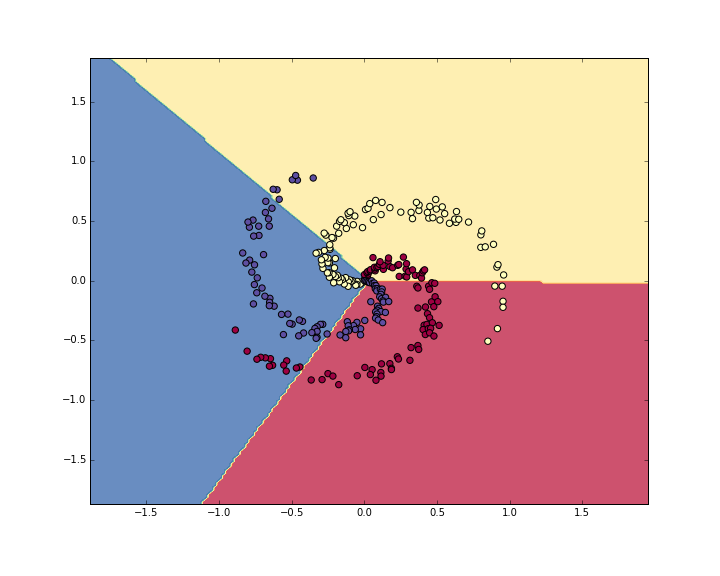

This gives approximately:

$$
54\%
$$

training accuracy.

This result is not very good, but it is also not surprising.

The spiral dataset was intentionally constructed so that the classes are not linearly separable.

A linear classifier can only create straight decision boundaries.

However, the spiral dataset requires curved and nonlinear decision boundaries.

Therefore, the Softmax linear classifier is not expressive enough for this dataset.

---

## Decision Boundary

We can also visualize the learned decision boundaries.

The linear classifier fails to separate the spiral dataset well because its decision regions are limited to linear shapes.

At this point, the main limitation is not the optimization procedure, but the model capacity.

To solve this problem, we need a more expressive model.

A 2-layer Neural Network can learn nonlinear decision boundaries and should perform much better on this dataset.

# Training a Neural Network

The linear classifier is not powerful enough for the spiral dataset.

This is because the spiral dataset is not linearly separable.

A linear classifier can only create linear decision boundaries, but this dataset requires nonlinear decision boundaries.

To solve this problem, we use a Neural Network.

For this toy dataset, one additional hidden layer is enough.

This gives us a **2-layer Neural Network**.

---

## Model Architecture

The network has:

- an input layer,
- one hidden layer,
- an output layer.

The input data has dimensionality:

$$
D = 2
$$

The number of classes is:

$$
K = 3
$$

We choose the hidden layer size as:

$$
h = 100
$$

Because the network now has two layers of learnable parameters, we need two sets of weights and biases:

- $W$ and $b$ for the first layer,
- $W_2$ and $b_2$ for the second layer.

The shapes are:

$$
W \in \mathbb{R}^{D \times h}
$$

$$
b \in \mathbb{R}^{1 \times h}
$$

$$
W_2 \in \mathbb{R}^{h \times K}
$$

$$
b_2 \in \mathbb{R}^{1 \times K}
$$

With the values in this example:

$$
W \in \mathbb{R}^{2 \times 100}
$$

$$
b \in \mathbb{R}^{1 \times 100}
$$

$$
W_2 \in \mathbb{R}^{100 \times 3}
$$

$$
b_2 \in \mathbb{R}^{1 \times 3}
$$

In [23]:
# initialize parameters randomly
h = 100  # size of hidden layer

W = 0.01 * np.random.randn(D, h)
b = np.zeros((1, h))

W2 = 0.01 * np.random.randn(h, K)
b2 = np.zeros((1, K))


---

## Forward Pass

The forward pass now changes slightly.

In the linear classifier, the scores were computed directly from the input:

$$
scores = XW + b
$$

For the 2-layer Neural Network, we first compute a hidden layer representation.

The hidden layer is computed as:

$$
hidden = \max(0, XW + b)
$$

Then the class scores are computed from the hidden layer:

$$
scores = hidden \cdot W_2 + b_2
$$

The function:

$$
\max(0, x)
$$

is the **ReLU activation function**.

ReLU introduces nonlinearity into the model.

This nonlinearity is crucial because it allows the network to learn nonlinear decision boundaries.

Without a nonlinearity, stacking multiple linear layers would still result in a linear model.

In [24]:
# evaluate class scores with a 2-layer Neural Network
hidden_layer = np.maximum(0, np.dot(X, W) + b)  # ReLU activation
scores = np.dot(hidden_layer, W2) + b2

The only major change from the linear classifier is the additional hidden layer computation.

First, the input data is transformed into a hidden representation.

Then, the final class scores are computed from this hidden representation.

Everything else remains mostly the same:

- the loss is still computed from the scores,
- the Softmax probabilities are computed in the same way,
- the gradient on the scores, `dscores`, is also computed in the same way.

However, backpropagation changes because the hidden layer is itself a function of the first-layer parameters.

# Backpropagation Through the Neural Network

The gradient first flows backward from the loss to the scores.

Then it must be backpropagated through the second layer, the hidden layer, the ReLU nonlinearity, and finally the first layer.

---

## Backpropagation Into the Second Layer

The second layer computes:

$$
scores = hidden \cdot W_2 + b_2
$$

Therefore, the gradients for the second-layer parameters are:

$$
dW_2 = hidden^T \cdot dscores
$$

$$
db_2 = \sum dscores
$$

This is very similar to the linear classifier case.

The only difference is that we use the hidden layer instead of the raw input data $X$.

In [25]:
# backpropagate the gradient to the second-layer parameters W2 and b2
dW2 = np.dot(hidden_layer.T, dscores)
db2 = np.sum(dscores, axis=0, keepdims=True)

---

## Backpropagation Into the Hidden Layer

We are not done yet.

The hidden layer is also a function of the input data and the first-layer parameters.

Therefore, we need to continue backpropagation through the hidden layer.

The gradient with respect to the hidden layer is:

$$
dhidden = dscores \cdot W_2^T
$$

In [26]:
# backpropagate into the hidden layer
dhidden = np.dot(dscores, W2.T)

---

## Backpropagation Through ReLU

The hidden layer uses the ReLU activation function:

$$
r = \max(0, x)
$$

The derivative of ReLU is:

$$
\frac{dr}{dx} = \mathbb{1}(x > 0)
$$

This means:

- if the input was greater than 0 during the forward pass, the gradient passes through unchanged,
- if the input was less than or equal to 0, the gradient becomes 0.

So during backpropagation, ReLU behaves like a switch.

It either lets the gradient pass through or blocks it.

In [27]:
# backpropagate the ReLU non-linearity
dhidden[hidden_layer <= 0] = 0

---

## Backpropagation Into the First Layer

After backpropagating through ReLU, we can compute the gradients for the first-layer parameters.

The first layer computes:

$$
hidden = \max(0, XW + b)
$$

The gradients are:

$$
dW = X^T \cdot dhidden
$$

$$
db = \sum dhidden
$$

In [28]:
# backpropagate into the first-layer parameters W and b
dW = np.dot(X.T, dhidden)
db = np.sum(dhidden, axis=0, keepdims=True)

Now we have all gradients required for training:

- $dW$,
- $db$,
- $dW_2$,
- $db_2$.

These gradients can be used to update the parameters using gradient descent.

The rest of the training procedure remains almost the same as before.

# Full Training Code for the 2-Layer Neural Network

Now we can put everything together.

The training loop for the 2-layer Neural Network is very similar to the Softmax linear classifier.

The main differences are:

- we compute a hidden layer using ReLU,
- we compute scores from the hidden layer,
- we backpropagate through the second layer,
- we backpropagate through ReLU,
- we backpropagate into the first layer.

The loss still contains two parts:

$$
L = L_{\text{data}} + L_{\text{reg}}
$$

Since the network has two weight matrices, the regularization loss becomes:

$$
L_{\text{reg}} =
\frac{1}{2}\lambda \sum W^2
+
\frac{1}{2}\lambda \sum W_2^2
$$

In [29]:
# initialize parameters randomly
h = 100  # size of hidden layer

W = 0.01 * np.random.randn(D, h)
b = np.zeros((1, h))

W2 = 0.01 * np.random.randn(h, K)
b2 = np.zeros((1, K))

# hyperparameters
step_size = 1e-0
reg = 1e-3  # regularization strength

# gradient descent loop
num_examples = X.shape[0]

for i in range(10000):

    # evaluate class scores, [N x K]
    hidden_layer = np.maximum(0, np.dot(X, W) + b)  # ReLU activation
    scores = np.dot(hidden_layer, W2) + b2

    # compute the class probabilities
    exp_scores = np.exp(scores)
    probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)  # [N x K]

    # compute the loss: average cross-entropy loss and regularization
    correct_logprobs = -np.log(probs[range(num_examples), y])
    data_loss = np.sum(correct_logprobs) / num_examples
    reg_loss = 0.5 * reg * np.sum(W * W) + 0.5 * reg * np.sum(W2 * W2)
    loss = data_loss + reg_loss

    if i % 1000 == 0:
        print("iteration %d: loss %f" % (i, loss))

    # compute the gradient on scores
    dscores = probs.copy()
    dscores[range(num_examples), y] -= 1
    dscores /= num_examples

    # backpropagate into second-layer parameters
    dW2 = np.dot(hidden_layer.T, dscores)
    db2 = np.sum(dscores, axis=0, keepdims=True)

    # backpropagate into hidden layer
    dhidden = np.dot(dscores, W2.T)

    # backpropagate the ReLU non-linearity
    dhidden[hidden_layer <= 0] = 0

    # backpropagate into first-layer parameters
    dW = np.dot(X.T, dhidden)
    db = np.sum(dhidden, axis=0, keepdims=True)

    # add regularization gradient contribution
    dW2 += reg * W2
    dW += reg * W

    # perform parameter update
    W += -step_size * dW
    b += -step_size * db
    W2 += -step_size * dW2
    b2 += -step_size * db2

iteration 0: loss 1.098623
iteration 1000: loss 0.320717
iteration 2000: loss 0.263231
iteration 3000: loss 0.252771
iteration 4000: loss 0.250346
iteration 5000: loss 0.249378
iteration 6000: loss 0.248679
iteration 7000: loss 0.248215
iteration 8000: loss 0.247854
iteration 9000: loss 0.247578


# evaluate training set accuracy
hidden_layer = np.maximum(0, np.dot(X, W) + b)
scores = np.dot(hidden_layer, W2) + b2

predicted_class = np.argmax(scores, axis=1)

print("training accuracy: %.2f" % (np.mean(predicted_class == y)))

In [30]:
# evaluate training set accuracy
hidden_layer = np.maximum(0, np.dot(X, W) + b)
scores = np.dot(hidden_layer, W2) + b2

predicted_class = np.argmax(scores, axis=1)

print("training accuracy: %.2f" % (np.mean(predicted_class == y)))

training accuracy: 0.99


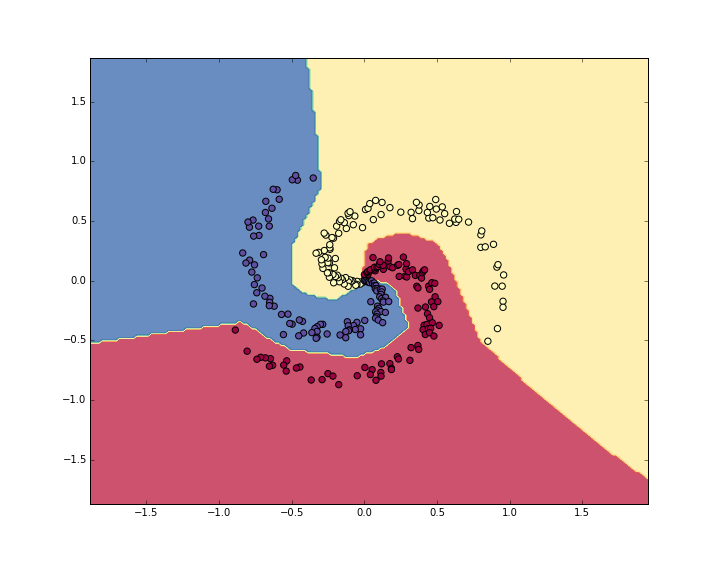


This gives approximately:

$$
99\%
$$

training accuracy.

This is a major improvement compared to the linear classifier, which achieved about:

$$
54\%
$$

training accuracy.

The improvement happens because the Neural Network can represent nonlinear decision boundaries.

---

## Decision Boundaries

We can also visualize the decision boundaries learned by the Neural Network.

Unlike the linear classifier, the Neural Network can bend and curve its decision regions to match the spiral structure of the data.

This shows that even adding a single hidden layer can significantly increase the expressive power of the model.
